# Pedestals June 19

In [1]:
from pathlib import Path
import pypff
from matplotlib import pyplot as plt
import numpy as np
import heap
import pandas as pd
from pedestal import *
from helpers import read_module_pffs

In [2]:
data_path_pre = "/Users/ravikularaman/VSCode-projects/Dark100/June2026/data/obs_Palomar.start_2026-06-19T07:14:25Z.runtype_obs-test.pffd"
data_winter_pre, ts_winter_pre, winter_files_pre = read_module_pffs(data_path_pre, apply_spike_cut=False, module=253)
data_fern_pre, ts_fern_pre, fern_files_pre = read_module_pffs(data_path_pre, apply_spike_cut=False, module=252)
data_pti_pre, ts_pti_pre, pti_files_pre = read_module_pffs(data_path_pre, apply_spike_cut=False, module=250)

data_path_post = "/Users/ravikularaman/VSCode-projects/Dark100/June2026/data/obs_Palomar.start_2026-06-19T10:06:40Z.runtype_obs-test.pffd"
data_winter_post, ts_winter_post, winter_files_post = read_module_pffs(data_path_post, apply_spike_cut=False, module=253)
data_fern_post, ts_fern_post, fern_files_post = read_module_pffs(data_path_post, apply_spike_cut=False, module=252)
data_pti_post, ts_pti_post, pti_files_post = read_module_pffs(data_path_post, apply_spike_cut=False, module=250)

Data read in, number of events:  14725
Number of Events with package loss:  14  ( 0.1 %)
Data read in, number of events:  19450
Number of Events with package loss:  13  ( 0.07 %)
Data read in, number of events:  19620
Number of Events with package loss:  16  ( 0.08 %)
Data read in, number of events:  4354
Number of Events with package loss:  4  ( 0.09 %)
Data read in, number of events:  5565
Number of Events with package loss:  0  ( 0.0 %)
Data read in, number of events:  5760
Number of Events with package loss:  0  ( 0.0 %)


# Pedestals and pedvars

In [3]:
pedestal_winter_pre, pedvar_winter_pre = calculate_pedestal_and_pedvar(data_winter_pre, fit_gaussian=True)
pedestal_fern_pre, pedvar_fern_pre = calculate_pedestal_and_pedvar(data_fern_pre, fit_gaussian=True)
pedestal_pti_pre, pedvar_pti_pre = calculate_pedestal_and_pedvar(data_pti_pre, fit_gaussian=True)

pedestal_winter_post, pedvar_winter_post = calculate_pedestal_and_pedvar(data_winter_post, fit_gaussian=True)
pedestal_fern_post, pedvar_fern_post = calculate_pedestal_and_pedvar(data_fern_post, fit_gaussian=True)
pedestal_pti_post, pedvar_pti_post = calculate_pedestal_and_pedvar(data_pti_post, fit_gaussian=True)

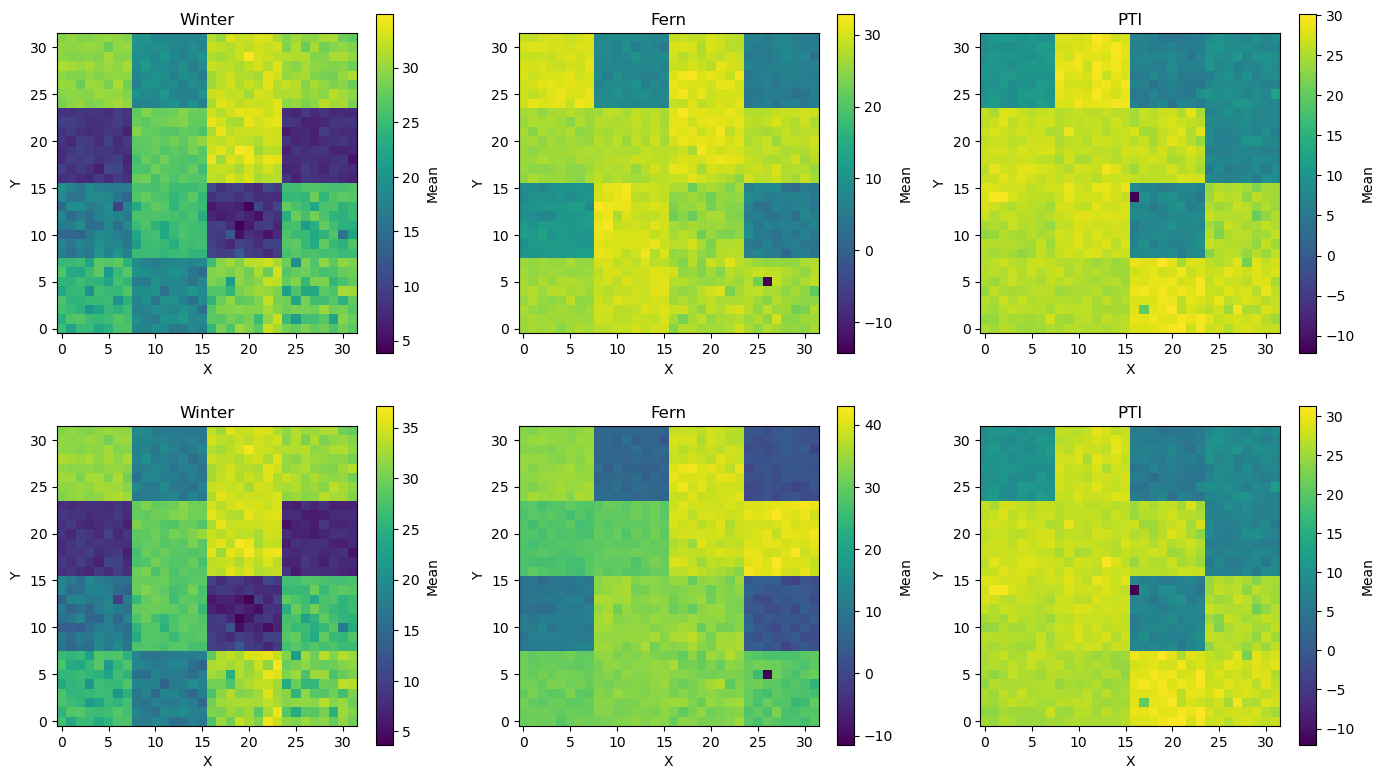

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

im1 = axes[0, 0].imshow(pedestal_winter_pre.reshape((32, 32)), origin='lower', cmap='viridis')
axes[0, 0].set_title('Winter')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Y')
plt.colorbar(im1, ax=axes[0, 0], label='Mean')

im2 = axes[0, 1].imshow(pedestal_fern_pre.reshape((32, 32)), origin='lower', cmap='viridis')
axes[0, 1].set_title('Fern')
axes[0, 1].set_xlabel('X')
axes[0, 1].set_ylabel('Y')
plt.colorbar(im2, ax=axes[0, 1], label='Mean')

im3 = axes[0, 2].imshow(pedestal_pti_pre.reshape((32, 32)), origin='lower', cmap='viridis')
axes[0, 2].set_title('PTI')
axes[0, 2].set_xlabel('X')
axes[0, 2].set_ylabel('Y')
plt.colorbar(im3, ax=axes[0, 2], label='Mean')

im1 = axes[1, 0].imshow(pedestal_winter_post.reshape((32, 32)), origin='lower', cmap='viridis')
axes[1, 0].set_title('Winter')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')
plt.colorbar(im1, ax=axes[1, 0], label='Mean')

im2 = axes[1, 1].imshow(pedestal_fern_post.reshape((32, 32)), origin='lower', cmap='viridis')
axes[1, 1].set_title('Fern')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y')
plt.colorbar(im2, ax=axes[1, 1], label='Mean')

im3 = axes[1, 2].imshow(pedestal_pti_post.reshape((32, 32)), origin='lower', cmap='viridis')
axes[1, 2].set_title('PTI')
axes[1, 2].set_xlabel('X')
axes[1, 2].set_ylabel('Y')
plt.colorbar(im3, ax=axes[1, 2], label='Mean')

plt.tight_layout()
plt.show()

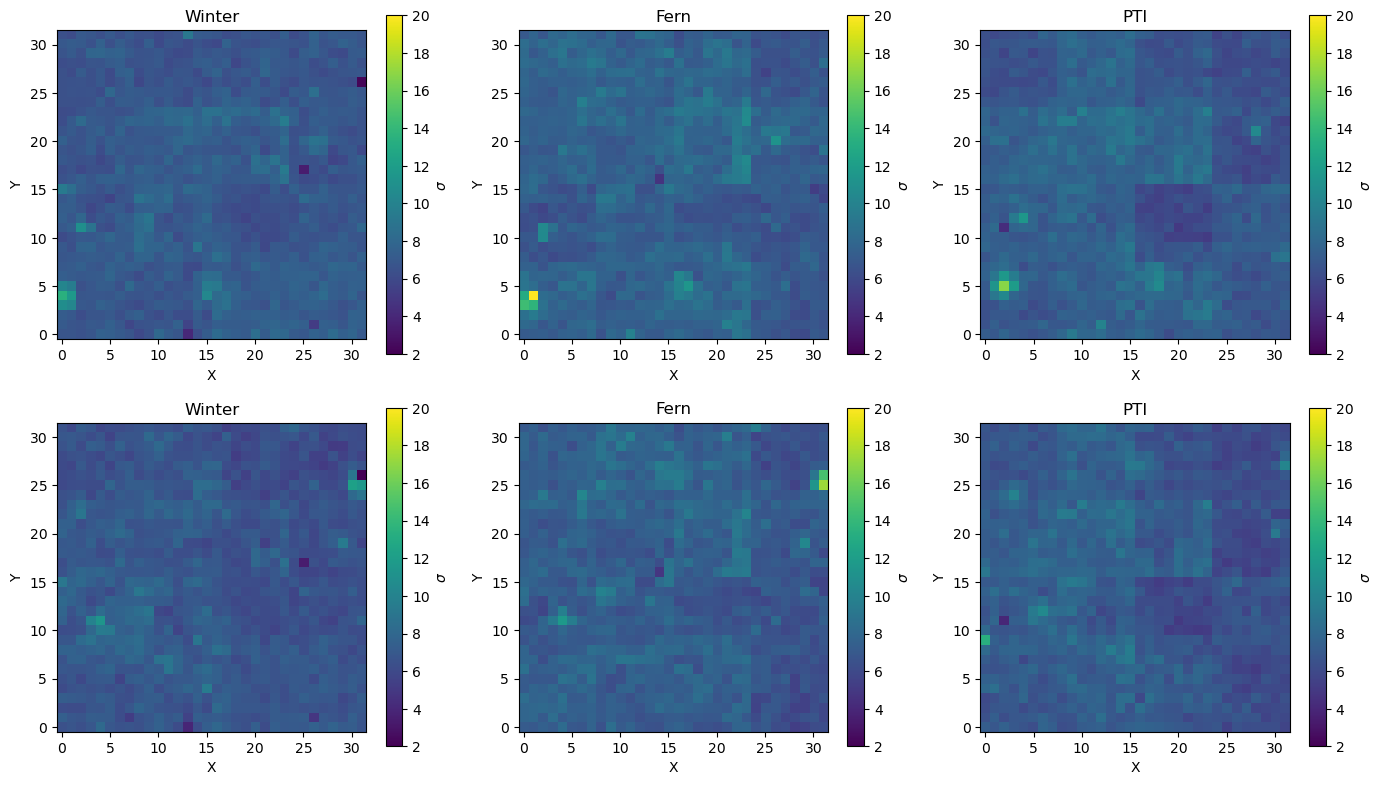

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

im1 = axes[0, 0].imshow(pedvar_winter_pre.reshape((32, 32)), origin='lower', cmap='viridis', vmin=2, vmax=20)
axes[0, 0].set_title('Winter')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Y')
plt.colorbar(im1, ax=axes[0, 0], label=r'$\sigma$')

im2 = axes[0, 1].imshow(pedvar_fern_pre.reshape((32, 32)), origin='lower', cmap='viridis', vmin=2, vmax=20)
axes[0, 1].set_title('Fern')
axes[0, 1].set_xlabel('X')
axes[0, 1].set_ylabel('Y')
plt.colorbar(im2, ax=axes[0, 1], label=r'$\sigma$')

im3 = axes[0, 2].imshow(pedvar_pti_pre.reshape((32, 32)), origin='lower', cmap='viridis', vmin=2, vmax=20)
axes[0, 2].set_title('PTI')
axes[0, 2].set_xlabel('X')
axes[0, 2].set_ylabel('Y')
plt.colorbar(im3, ax=axes[0, 2], label=r'$\sigma$')

im1 = axes[1, 0].imshow(pedvar_winter_post.reshape((32, 32)), origin='lower', cmap='viridis', vmin=2, vmax=20)
axes[1, 0].set_title('Winter')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')
plt.colorbar(im1, ax=axes[1, 0], label=r'$\sigma$')

im2 = axes[1, 1].imshow(pedvar_fern_post.reshape((32, 32)), origin='lower', cmap='viridis', vmin=2, vmax=20)
axes[1, 1].set_title('Fern')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y')
plt.colorbar(im2, ax=axes[1, 1], label=r'$\sigma$')

im3 = axes[1, 2].imshow(pedvar_pti_post.reshape((32, 32)), origin='lower', cmap='viridis', vmin=2, vmax=20)
axes[1, 2].set_title('PTI')
axes[1, 2].set_xlabel('X')
axes[1, 2].set_ylabel('Y')
plt.colorbar(im3, ax=axes[1, 2], label=r'$\sigma$')

plt.tight_layout()
plt.show()

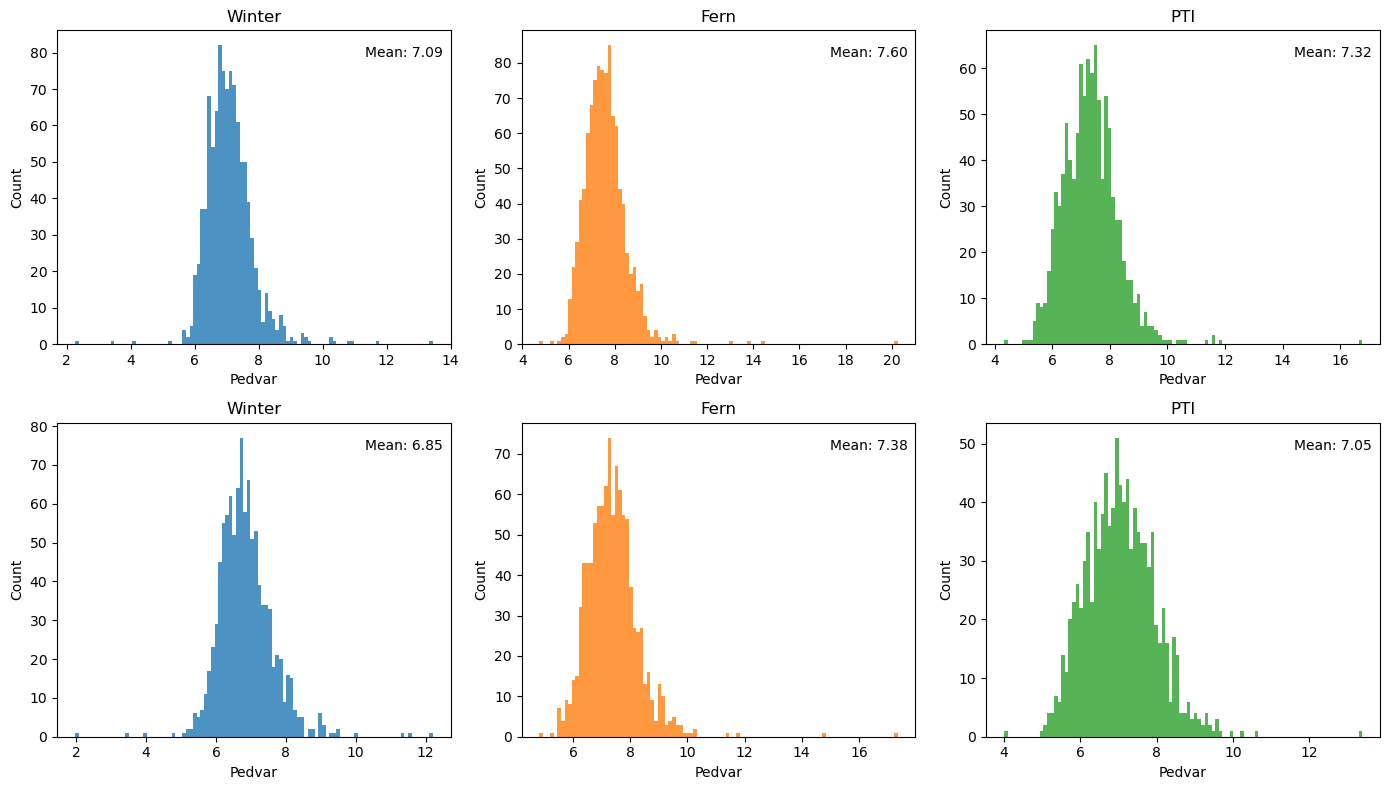

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Winter pre
axes[0, 0].hist(pedvar_winter_pre, bins=100, color="tab:blue", alpha=0.8, linewidth=0.4)
axes[0, 0].text(0.98, 0.95, f"Mean: {np.mean(pedvar_winter_pre):.2f}", transform=axes[0, 0].transAxes, ha="right", va="top", fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.75))
axes[0, 0].set_title('Winter')
axes[0, 0].set_xlabel('Pedvar')
axes[0, 0].set_ylabel('Count')

# Fern pre
axes[0, 1].hist(pedvar_fern_pre, bins=100, color="tab:orange", alpha=0.8, linewidth=0.4)
axes[0, 1].text(0.98, 0.95, f"Mean: {np.mean(pedvar_fern_pre):.2f}", transform=axes[0, 1].transAxes, ha="right", va="top", fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.75))
axes[0, 1].set_title('Fern')
axes[0, 1].set_xlabel('Pedvar')
axes[0, 1].set_ylabel('Count')

# PTI pre
axes[0, 2].hist(pedvar_pti_pre, bins=100, color="tab:green", alpha=0.8, linewidth=0.4)
axes[0, 2].text(0.98, 0.95, f"Mean: {np.mean(pedvar_pti_pre):.2f}", transform=axes[0, 2].transAxes, ha="right", va="top", fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.75))
axes[0, 2].set_title('PTI')
axes[0, 2].set_xlabel('Pedvar')
axes[0, 2].set_ylabel('Count')

# Winter post
axes[1, 0].hist(pedvar_winter_post, bins=100, color="tab:blue", alpha=0.8, linewidth=0.4)
axes[1, 0].text(0.98, 0.95, f"Mean: {np.mean(pedvar_winter_post):.2f}", transform=axes[1, 0].transAxes, ha="right", va="top", fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.75))
axes[1, 0].set_title('Winter')
axes[1, 0].set_xlabel('Pedvar')
axes[1, 0].set_ylabel('Count')

# Fern post
axes[1, 1].hist(pedvar_fern_post, bins=100, color="tab:orange", alpha=0.8, linewidth=0.4)
axes[1, 1].text(0.98, 0.95, f"Mean: {np.mean(pedvar_fern_post):.2f}", transform=axes[1, 1].transAxes, ha="right", va="top", fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.75))
axes[1, 1].set_title('Fern')
axes[1, 1].set_xlabel('Pedvar')
axes[1, 1].set_ylabel('Count')

# PTI post
axes[1, 2].hist(pedvar_pti_post, bins=100, color="tab:green", alpha=0.8, linewidth=0.4)
axes[1, 2].text(0.98, 0.95, f"Mean: {np.mean(pedvar_pti_post):.2f}", transform=axes[1, 2].transAxes, ha="right", va="top", fontsize=10, bbox=dict(facecolor="white", edgecolor="none", alpha=0.75))
axes[1, 2].set_title('PTI')
axes[1, 2].set_xlabel('Pedvar')
axes[1, 2].set_ylabel('Count')

plt.tight_layout()
plt.show()


# Pedestals over time

In [7]:
interval_minutes = 10
nsig = 5

# Concatenate pre and post data
data_winter = np.concatenate([data_winter_pre, data_winter_post], axis=0)
ts_winter = np.concatenate([ts_winter_pre, ts_winter_post], axis=0)

data_fern = np.concatenate([data_fern_pre, data_fern_post], axis=0)
ts_fern = np.concatenate([ts_fern_pre, ts_fern_post], axis=0)

data_pti = np.concatenate([data_pti_pre, data_pti_post], axis=0)
ts_pti = np.concatenate([ts_pti_pre, ts_pti_post], axis=0)

# Create unified timestamps and intervals
timestamps_winter = pd.to_datetime(ts_winter, unit='s', utc=True)
timestamps_fern = pd.to_datetime(ts_fern, unit='s', utc=True)
timestamps_pti = pd.to_datetime(ts_pti, unit='s', utc=True)

# Find overall start/end times across all detectors and pre/post
start_time = min(timestamps_winter.min(), timestamps_fern.min(), timestamps_pti.min())
end_time = max(timestamps_winter.max(), timestamps_fern.max(), timestamps_pti.max())

# Create intervals on full range
interval_delta = pd.Timedelta(minutes=interval_minutes)
intervals = pd.date_range(start=start_time, end=end_time, freq=interval_delta)
if intervals[-1] < end_time:
    intervals = intervals.append(pd.DatetimeIndex([end_time]))

n_intervals = len(intervals) - 1

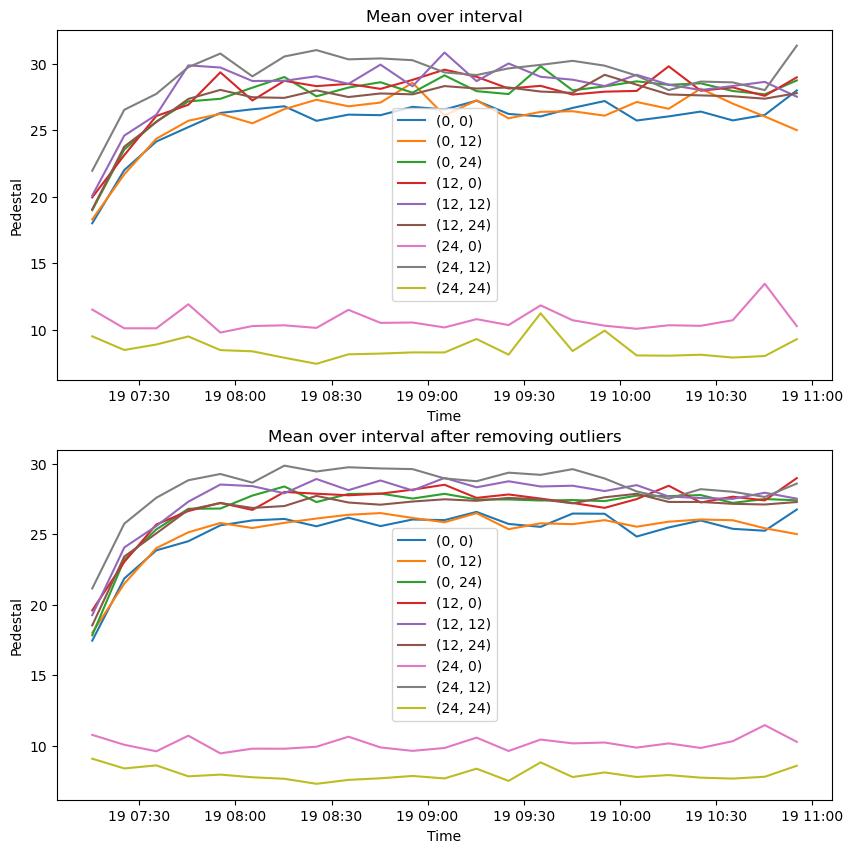

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

for ix in range(0, 32, 12):
    for iy in range(0, 32, 12):

        ts = ts_pti

        peds_over_time, peds_over_time_woutliers = np.zeros(n_intervals), np.zeros(n_intervals)

        for i in range(n_intervals):

            start_interval = intervals[i]
            end_interval = intervals[i+1]

            ts_df = pd.to_datetime(ts, unit="s", utc=True)
            start_idx = ts_df.searchsorted(start_interval, side="left")
            end_idx = ts_df.searchsorted(end_interval, side="right")

            data_slice = data_pti.reshape(-1, 32, 32)[start_idx:end_idx, ix, iy]
    
            mean, std = np.nanmean(data_slice), np.abs(np.nanstd(data_slice))
    
            thr = mean + nsig * std
            data_masked = np.where(data_slice < thr, data_slice, np.nan)
            mean_2 = np.nanmean(data_masked)
    
            peds_over_time[i] = mean
            peds_over_time_woutliers[i] = mean_2

        axes[0].plot(intervals[:-1], peds_over_time, label=f"({ix}, {iy})")
        axes[1].plot(intervals[:-1], peds_over_time_woutliers, label=f"({ix}, {iy})")

axes[0].set_xlabel("Time")
axes[0].set_ylabel("Pedestal")
axes[0].set_title("Mean over interval")
axes[0].legend()

axes[1].set_xlabel("Time")
axes[1].set_ylabel("Pedestal")
axes[1].set_title("Mean over interval after removing outliers")
axes[1].legend()

plt.show()

In [8]:
interval_minutes = 30
nsig = 5
n_bins = None

timestamps_winter_pre = pd.to_datetime(ts_winter_pre, unit='s', utc=True)
timestamps_fern_pre = pd.to_datetime(ts_fern_pre, unit='s', utc=True)
timestamps_pti_pre = pd.to_datetime(ts_pti_pre, unit='s', utc=True)

start_time_pre = min(timestamps_winter_pre.min(), timestamps_fern_pre.min(), timestamps_pti_pre.min())
end_time_pre = max(timestamps_winter_pre.max(), timestamps_fern_pre.max(), timestamps_pti_pre.max())

timestamps_winter_post = pd.to_datetime(ts_winter_post, unit='s', utc=True)
timestamps_fern_post = pd.to_datetime(ts_fern_post, unit='s', utc=True)
timestamps_pti_post = pd.to_datetime(ts_pti_post, unit='s', utc=True)

start_time_post = min(timestamps_winter_post.min(), timestamps_fern_post.min(), timestamps_pti_post.min())
end_time_post = max(timestamps_winter_post.max(), timestamps_fern_post.max(), timestamps_pti_post.max())

In [9]:
print("Timestamps (pre):")
print(start_time_pre)
print(end_time_pre)
print("Timestamps (post):")
print(start_time_post)
print(end_time_post)

interval_delta = pd.Timedelta(minutes=interval_minutes)
intervals_pre = pd.date_range(start=start_time_pre, end=end_time_pre, freq=interval_delta)
if intervals_pre[-1] < end_time_pre:
    intervals_pre = intervals_pre.append(pd.DatetimeIndex([end_time_pre]))
print("intervals (pre):", intervals_pre)

intervals_post = pd.date_range(start=start_time_post, end=end_time_post, freq=interval_delta)
if intervals_post[-1] < end_time_post:
    intervals_post = intervals_post.append(pd.DatetimeIndex([end_time_post]))
print("intervals (post):", intervals_post)

n_intervals_pre = len(intervals_pre) - 1
n_cols_pre=4
n_rows_pre=int(np.ceil(n_intervals_pre / n_cols_pre))

n_intervals_post = len(intervals_post) - 1
n_cols_post=3
n_rows_post=int(np.ceil(n_intervals_post / n_cols_post))

Timestamps (pre):
2026-06-19 07:15:16.751016481+00:00
2026-06-19 10:01:49.421331432+00:00
Timestamps (post):
2026-06-19 10:07:31.776542273+00:00
2026-06-19 10:56:31.410228283+00:00
intervals (pre): DatetimeIndex(['2026-06-19 07:15:16.751016481+00:00',
               '2026-06-19 07:45:16.751016481+00:00',
               '2026-06-19 08:15:16.751016481+00:00',
               '2026-06-19 08:45:16.751016481+00:00',
               '2026-06-19 09:15:16.751016481+00:00',
               '2026-06-19 09:45:16.751016481+00:00',
               '2026-06-19 10:01:49.421331432+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)
intervals (post): DatetimeIndex(['2026-06-19 10:07:31.776542273+00:00',
               '2026-06-19 10:37:31.776542273+00:00',
               '2026-06-19 10:56:31.410228283+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)


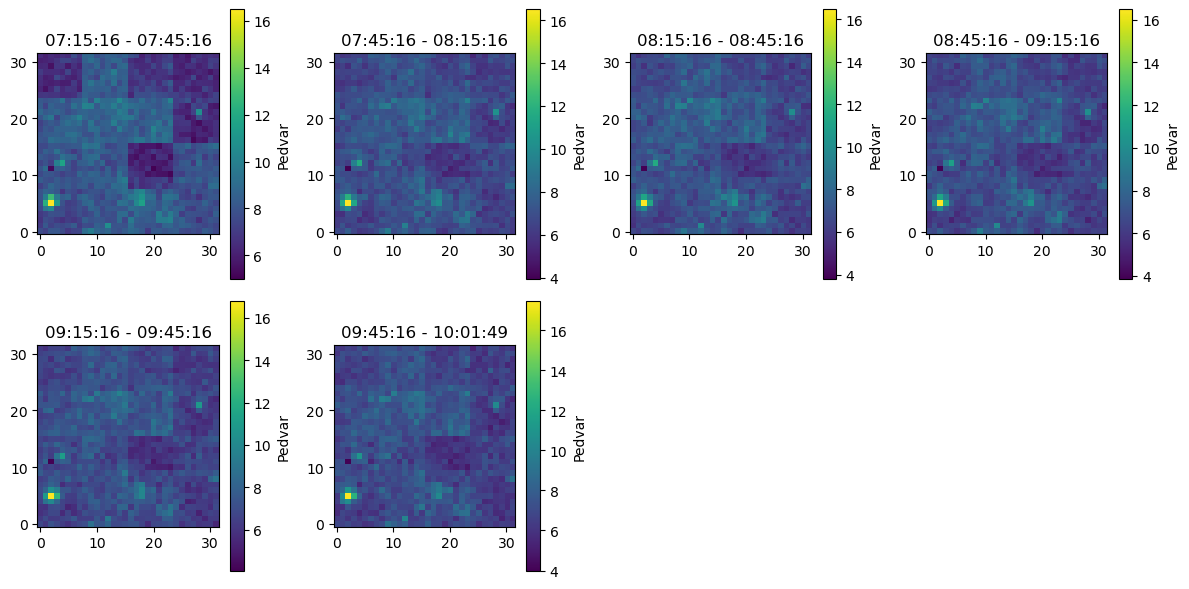

In [14]:
n_rows, n_cols, n_intervals, intervals = n_rows_pre, n_cols_pre, n_intervals_pre, intervals_pre

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3*n_rows))
axes = axes.flatten()  # Flatten to 1D array for easier indexing
    
# Loop through intervals and calculate pedvar
for i in range(n_intervals):
    start_interval = intervals[i]
    end_interval = intervals[i+1]
    #print(end_interval)
    try:
        pedestal, pedvar, _, _ = calculate_pedestal_and_pedvar_on_interval_from_array(data_pti_pre, timestamps_pti_pre, start_interval, end_interval, nsig=5, fit_gaussian=True)
        #print(pedvar)
        
        # Plot pedvar for this interval as 32x32 heatmap
        ax = axes[i]
        ped_var_image = pedvar.reshape((32, 32))
        im = ax.imshow(ped_var_image, origin='lower', cmap='viridis')
        ax.set_title(f'{intervals[i].strftime("%H:%M:%S")} - {intervals[i+1].strftime("%H:%M:%S")}')
        plt.colorbar(im, ax=ax, label='Pedvar')
        
    except Exception as e:
        ax = axes[i]
        ax.text(0.5, 0.5, f'Error: {str(e)}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{intervals[i].strftime("%H:%M:%S")} - {intervals[i+1].strftime("%H:%M:%S")}')
    
# Hide unused subplots
for j in range(n_intervals, len(axes)):
    axes[j].axis('off')

plt.tight_layout()

plt.show()

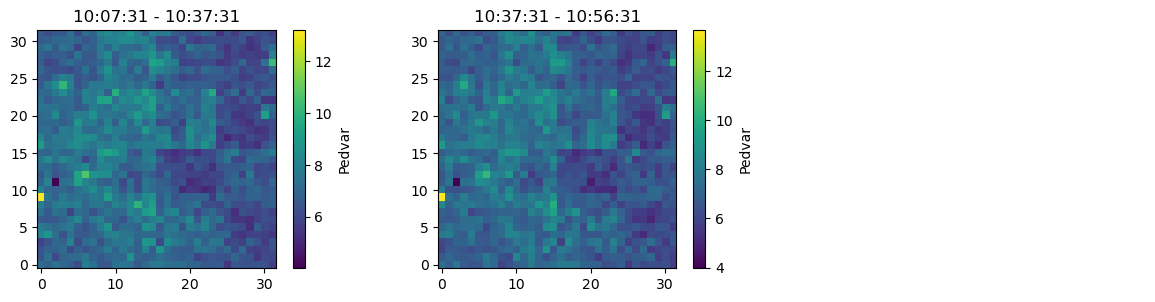

In [15]:
n_rows, n_cols, n_intervals, intervals = n_rows_post, n_cols_post, n_intervals_post, intervals_post

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3*n_rows))
axes = axes.flatten()  # Flatten to 1D array for easier indexing
    
# Loop through intervals and calculate pedvar
for i in range(n_intervals):
    start_interval = intervals[i]
    end_interval = intervals[i+1]
    #print(end_interval)
    try:
        pedestal, pedvar, _, _ = calculate_pedestal_and_pedvar_on_interval_from_array(data_pti_post, timestamps_pti_post, start_interval, end_interval, nsig=5, fit_gaussian=True)
        #print(pedvar)
        
        # Plot pedvar for this interval as 32x32 heatmap
        ax = axes[i]
        ped_var_image = pedvar.reshape((32, 32))
        im = ax.imshow(ped_var_image, origin='lower', cmap='viridis')
        ax.set_title(f'{intervals[i].strftime("%H:%M:%S")} - {intervals[i+1].strftime("%H:%M:%S")}')
        plt.colorbar(im, ax=ax, label='Pedvar')
        
    except Exception as e:
        ax = axes[i]
        ax.text(0.5, 0.5, f'Error: {str(e)}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{intervals[i].strftime("%H:%M:%S")} - {intervals[i+1].strftime("%H:%M:%S")}')
    
# Hide unused subplots
for j in range(n_intervals, len(axes)):
    axes[j].axis('off')

plt.tight_layout()

plt.show()